# Hands-on: Transfer Learning for Multiclass Steel Defect Classification

## **Local Environment Setup**

**If you are running this notebook locally**, first create a virtual environment and install the required libraries.

```bash
python -m venv workshop-env
source workshop-env/bin/activate
python -m pip install --upgrade pip
pip install torch torchvision torchaudio pandas matplotlib scikit-learn seaborn torchinfo
```

**If you are using the LUMI notebook environment, simply select the `Python 3` kernel and run the cells.**

In [31]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, models
from torchinfo import summary

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

#read information about each library. help(random_split), random_split?,  print(random_split.__doc__), random_split(shift+tab)

Using device: cuda


# Dataset Setup: Severstal Defect Dataset

We uses the `Severstal: Steel Defect Detection` dataset, containing 200 images each of 4 defect types:
- **Scratches**: Surface scratches and abrasions
- **Inclusions**: Foreign particles embedded in steel
- **Patches**: Localized surface irregularities  
- **Rolls Marks**: Marks from the rolling process

Directory structure:
```
single_class_sampled/
├── Scratches/      
├── Inclusions/     
├── Patches/         
└── Rolls Marks/    
```

In [32]:
# Define path to dataset
dataset_path = r"/projappl/project_465002387/DEEP_Inspection_Material_Science/data/single_class_sampled"

if not os.path.exists(dataset_path):
    print(f"Error: {dataset_path} folder not found!")
else:
    print(f"Dataset path: {os.path.abspath(dataset_path)}")

Dataset path: /projappl/project_465002387/DEEP_Inspection_Material_Science/data/single_class_sampled


In [33]:
# Get sorted class names
class_names = sorted(os.listdir(dataset_path))
print(f"Classes found: {class_names}")
print(f"Number of classes: {len(class_names)}")

# Count images per class
for class_name in class_names:
    class_path = os.path.join(dataset_path, class_name)
    num_images = len([f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
    print(f"{class_name}: {num_images} images")


Classes found: ['Inclusions', 'Patches', 'Rolls Marks', 'Scratches']
Number of classes: 4
Inclusions: 195 images
Patches: 500 images
Rolls Marks: 500 images
Scratches: 500 images


In [34]:
# Load full dataset
BATCH_SIZE = 32
IMAGE_SIZE = 255

# PyTorch transforms (normalize with ImageNet stats for transfer learning)
base_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(root=dataset_path,
                                    transform=base_transform)

# Extract all images and labels as arrays for splitting
all_indices = list(range(len(full_dataset)))
all_labels  = [full_dataset.targets[i] for i in all_indices]

# First split: 70% train, 30% holdout (val + test)
train_idx, holdout_idx = train_test_split(
    all_indices, test_size=0.3, random_state=0, stratify=all_labels
)

holdout_labels = [all_labels[i] for i in holdout_idx]

# Second split: 15% val, 15% test
val_idx, test_idx = train_test_split(
    holdout_idx, test_size=0.5, random_state=0, stratify=holdout_labels
)

# Subset samplers
from torch.utils.data import Subset
train_dataset = Subset(full_dataset, train_idx)
val_dataset   = Subset(full_dataset, val_idx)
test_dataset  = Subset(full_dataset, test_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Total images:       {len(full_dataset)}")
print(f"Training samples:   {len(train_dataset)} ({len(train_dataset)/len(full_dataset)*100:.1f}%)")
print(f"Validation samples: {len(val_dataset)}   ({len(val_dataset)/len(full_dataset)*100:.1f}%)")
print(f"Test samples:       {len(test_dataset)}   ({len(test_dataset)/len(full_dataset)*100:.1f}%)")


Total images:       1695
Training samples:   1186 (70.0%)
Validation samples: 254   (15.0%)
Test samples:       255   (15.0%)


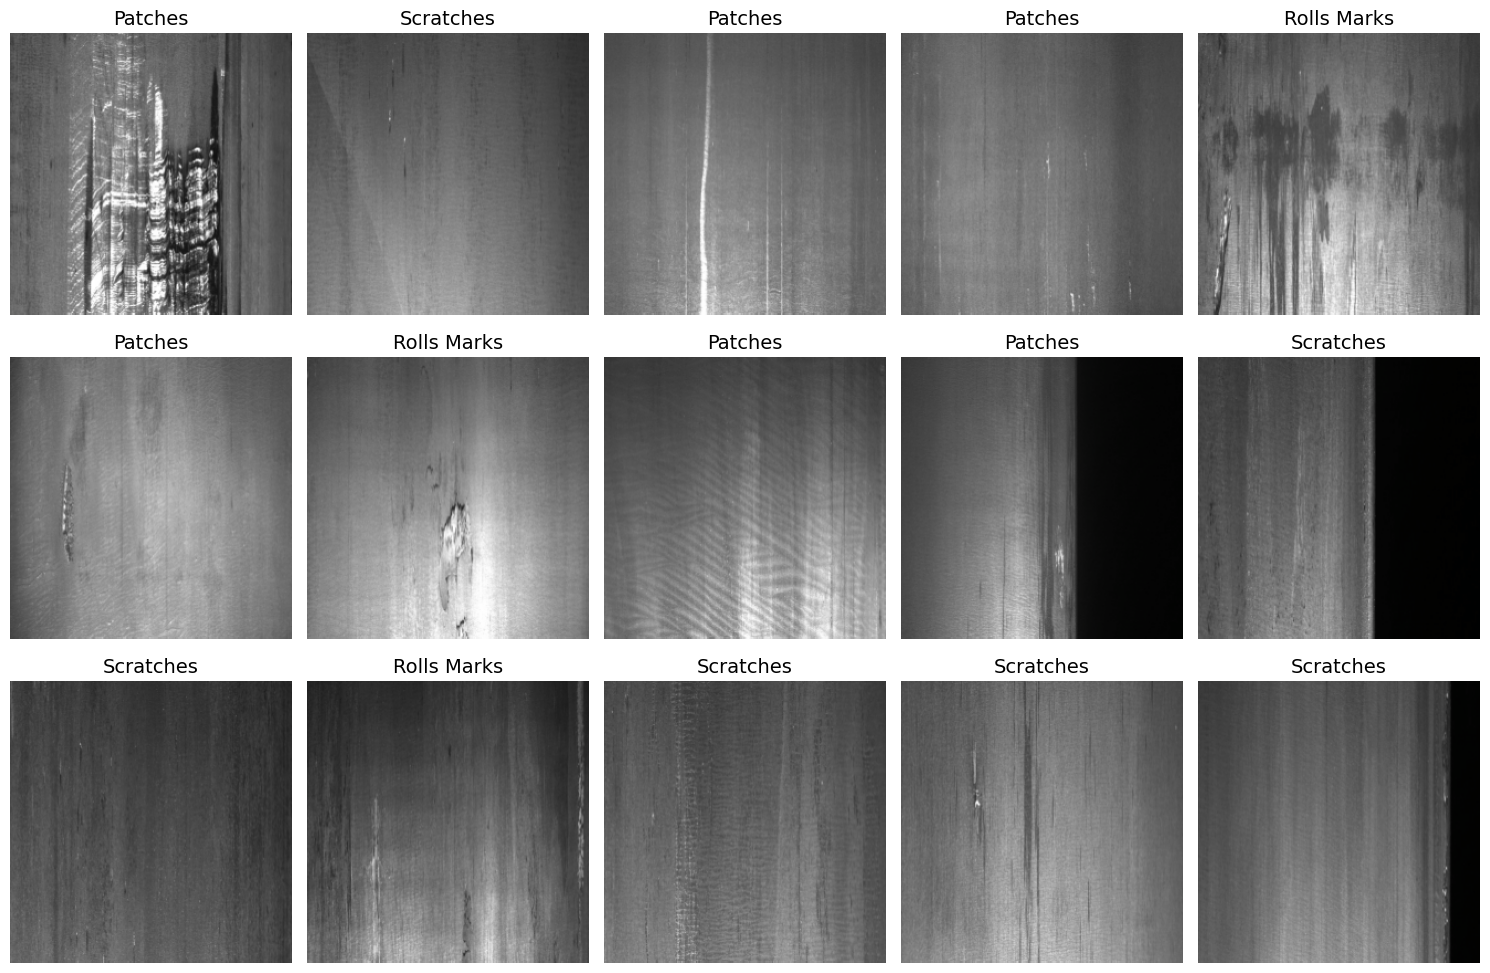

In [5]:
# Visualize sample images from training set
# (un-normalize for display)
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

plt.figure(figsize=(15, 10))
images_batch, labels_batch = next(iter(train_loader))
for i in range(min(15, len(images_batch))):
    ax = plt.subplot(3, 5, i + 1)
    img = inv_normalize(images_batch[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(class_names[labels_batch[i].item()], fontsize=14)
    plt.axis('off')
plt.tight_layout()
plt.show()


## Data Augmentation

In [35]:
from torch.utils.data import Subset, ConcatDataset

def augment_dataset(dataset, multiplier):
    """
    Return an augmented version of a dataset Subset, repeated `multiplier` times.
    """
    # Augmentations tailored for steel-surface defects: orientation-agnostic
    # flips/rotations, mild geometric jitter, lighting variation.
    # Normalization matches the original base_transform (ImageNet stats).
    
    augment_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=30),
        transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.9, 1.1)),
        transforms.ColorJitter(brightness=0.25, contrast=0.25),
        transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.2),
        transforms.ToTensor(),
        transforms.RandomErasing(p=0.20, scale=(0.02, 0.10)),  # occlusion robustness
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    # Recover the original ImageFolder root and this subset's indices
    root = dataset.dataset.root
    indices = dataset.indices

    # Augmented "view" of the same folder, same samples, new transform
    augmented_base = datasets.ImageFolder(root=root, transform=augment_transform)
    augmented_subset = Subset(augmented_base, indices)

    return ConcatDataset([augmented_subset] * multiplier)



# --- Apply augmentation to the training split ----------------

AUG_MULTIPLIER = 4
train_dataset2 = augment_dataset(train_dataset, multiplier=AUG_MULTIPLIER)
train_loader = DataLoader(train_dataset2, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)


print(f"Training samples: {len(train_dataset2)} ({AUG_MULTIPLIER}x, on-the-fly augmentation)")
print(f"Validation samples: {len(val_dataset)}  ")
print(f"Test samples:       {len(test_dataset)} ")

Training samples: 4744 (4x, on-the-fly augmentation)
Validation samples: 254  
Test samples:       255 


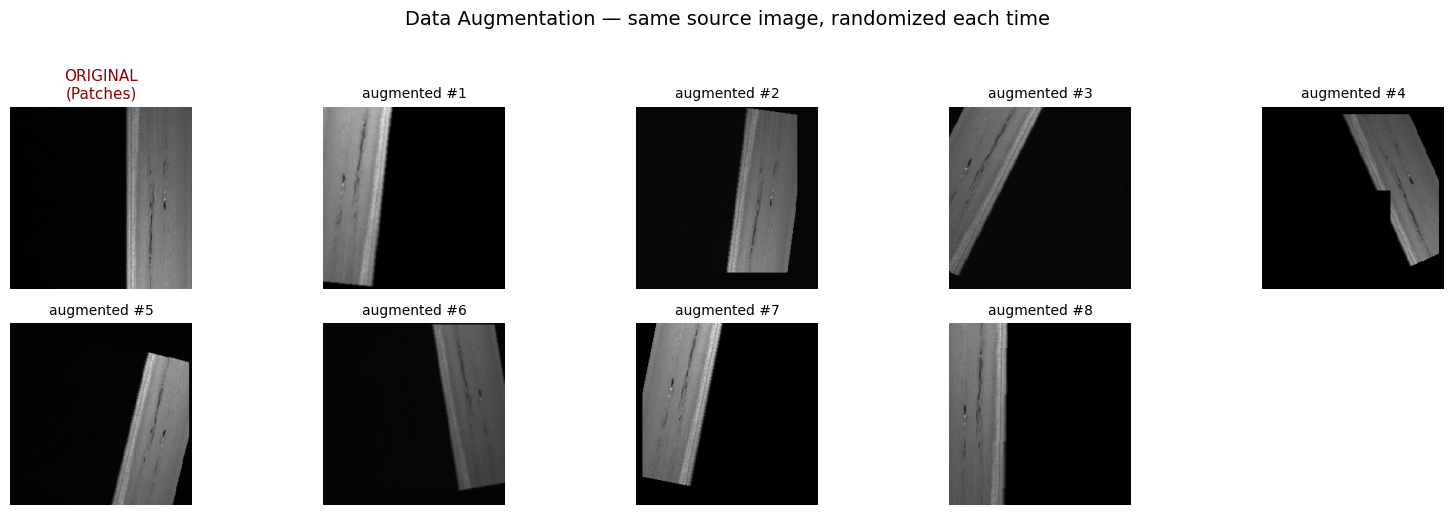

In [36]:
# --- Visualize the augmentations ----
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

from PIL import Image
import random

# Grab one RANDOM source image + its transform from the augmented training set
aug_subset = train_dataset2.datasets[0]            # the Subset inside ConcatDataset
aug_base = aug_subset.dataset                       # the augmented ImageFolder
sample_idx = random.choice(aug_subset.indices)      # random → different defect each run
src_path, src_label = aug_base.imgs[sample_idx][0], aug_base.targets[sample_idx]
pil_img = Image.open(src_path).convert("RGB")

n_show = 8
plt.figure(figsize=(16, 5))

ax = plt.subplot(2, (n_show // 2) + 1, 1)
plt.imshow(pil_img.resize((IMAGE_SIZE, IMAGE_SIZE)))
plt.title(f"ORIGINAL\n({class_names[src_label]})", fontsize=11, color="darkred")
plt.axis("off")

for i in range(n_show):
    ax = plt.subplot(2, (n_show // 2) + 1, i + 2)
    aug_tensor = aug_base.transform(pil_img)
    img = inv_normalize(aug_tensor).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(f"augmented #{i+1}", fontsize=10)
    plt.axis("off")

plt.suptitle("Data Augmentation — same source image, randomized each time",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Transfer Learning Using the VGG16 for Multiclass Steel Defect Classification

In [15]:
vgg16_backbone = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

summary(
    vgg16_backbone,
    input_size=(1,3,224,224),
    depth=10,
    col_names=["input_size", "output_size", "kernel_size", "num_params"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Kernel Shape              Param #
VGG                                      [1, 3, 224, 224]          [1, 1000]                 --                        --
├─Sequential: 1-1                        [1, 3, 224, 224]          [1, 512, 7, 7]            --                        --
│    └─Conv2d: 2-1                       [1, 3, 224, 224]          [1, 64, 224, 224]         [3, 3]                    1,792
│    └─ReLU: 2-2                         [1, 64, 224, 224]         [1, 64, 224, 224]         --                        --
│    └─Conv2d: 2-3                       [1, 64, 224, 224]         [1, 64, 224, 224]         [3, 3]                    36,928
│    └─ReLU: 2-4                         [1, 64, 224, 224]         [1, 64, 224, 224]         --                        --
│    └─MaxPool2d: 2-5                    [1, 64, 224, 224]         [1, 64, 112, 112]         2                         --
│    └─Conv2

In [20]:
class VGG16_Model(nn.Module):
    def __init__(self, num_classes):
        super(VGG16_Model, self).__init__()

        # Load pretrained VGG16
        self.vgg16 = models.vgg16(
            weights=models.VGG16_Weights.IMAGENET1K_V1
        )
        # Freeze all pretrained layers
        for param in self.vgg16.parameters():
            param.requires_grad = False

        # Remove the last classifier layer (1000 ImageNet classes)
        self.vgg16.classifier = nn.Sequential(
            *list(self.vgg16.classifier.children())[:-1]
        )

        # Add your own classifier
        self.own_layers = nn.Sequential(
            nn.Linear(4096, 512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.vgg16(x)       # output from modified VGG16 classifier = 4096 features
        x = self.own_layers(x)  # your classifier
        return x

# Build model
model_vgg16 = VGG16_Model(num_classes=len(class_names)).to(device)

# Model summary
summary(
    model_vgg16,
    input_size=(1,3,224,224),
    depth=10,
    col_names=["input_size", "output_size", "kernel_size", "num_params"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Kernel Shape              Param #
VGG16_Model                              [1, 3, 224, 224]          [1, 4]                    --                        --
├─VGG: 1-1                               [1, 3, 224, 224]          [1, 4096]                 --                        --
│    └─Sequential: 2-1                   [1, 3, 224, 224]          [1, 512, 7, 7]            --                        --
│    │    └─Conv2d: 3-1                  [1, 3, 224, 224]          [1, 64, 224, 224]         [3, 3]                    (1,792)
│    │    └─ReLU: 3-2                    [1, 64, 224, 224]         [1, 64, 224, 224]         --                        --
│    │    └─Conv2d: 3-3                  [1, 64, 224, 224]         [1, 64, 224, 224]         [3, 3]                    (36,928)
│    │    └─ReLU: 3-4                    [1, 64, 224, 224]         [1, 64, 224, 224]         --                        --
│    │  

In [8]:
def train_model(model, train_loader, val_loader, optimizer, criterion, epochs, model_name="Model"):
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    
    # ---- Training ----
    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)            
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item() 
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc  = correct / total

        # ---- Validation ----
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss / len(train_loader)
        val_acc   = val_correct / val_total

        history['loss'].append(train_loss)
        history['accuracy'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}]  "
              f"loss: {train_loss:.4f}  acc: {train_acc:.4f}  "
              f"val_loss: {val_loss:.4f}  val_acc: {val_acc:.4f}")

    print("\nTraining completed!")
    return history

In [ ]:
# If you are running on the LUMI cluster, do not execute this cell interactively. Instead, submit the script as a batch job to the SLURM queue system:
# sbatch run.sh VGG_transferlearning.py

criterion = nn.CrossEntropyLoss()
optimizer_vgg16 = optim.Adam(model_vgg16.parameters(), lr=0.001)

EPOCHS = 10
start = time.time()
print("Training VGG16 Transfer Learning Model...")
history_vgg16 = train_model(
    model_vgg16,
    train_loader,
    val_loader,
    optimizer_vgg16,
    criterion,
    EPOCHS,
    "VGG16"
)

# Training time
end_time = time.time()
print(f"\nTotal training time: {(end_time-start_time):.2f} seconds")
print(f"Average time per epoch: {(end_time-start_time)/EPOCHS:.2f} seconds")


# Save VGG16 Model
torch.save(model_vgg16.state_dict(), 'model_vgg16_model.pth')
print("VGG16 model saved as 'model_vgg16_model.pth'")

In [24]:
#load the tranied model and history of training
storage_path = f"/projappl/project_465002387/DEEP_Inspection_Material_Science/users/{os.environ['USER']}/"
model_path = os.path.join(storage_path, "models", "vgg16_defect_classifier.pth")
checkpoint = torch.load(model_path, map_location=device)

model_vgg16 =  VGG16_Model(num_classes=len(class_names)).to(device)

model_vgg16.load_state_dict(checkpoint["model_state_dict"])
model_vgg16.eval()

history_vgg16 = checkpoint["history"]
print(f"Loaded model from: {model_path}")

Loaded model from: /projappl/project_465002387/DEEP_Inspection_Material_Science/users/saeedima/models/vgg16_defect_classifier.pth


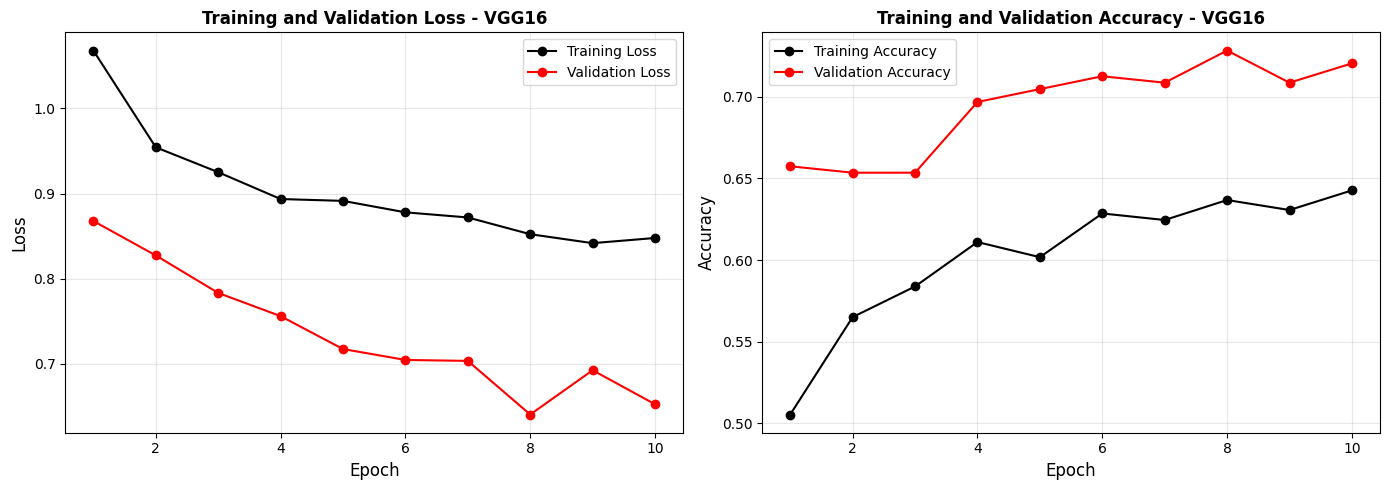

In [25]:
# Plot Training History for VGG16
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(np.arange(1, len(history_vgg16["loss"]) + 1), history_vgg16['loss'],
             color='black', label='Training Loss', marker='o')
axes[0].plot(np.arange(1, len(history_vgg16["loss"]) + 1), history_vgg16['val_loss'],
             color='red', label='Validation Loss', marker='o')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss - VGG16', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(np.arange(1, len(history_vgg16["loss"]) + 1), history_vgg16['accuracy'],
             color='black', label='Training Accuracy', marker='o')
axes[1].plot(np.arange(1, len(history_vgg16["loss"]) + 1), history_vgg16['val_accuracy'],
             color='red', label='Validation Accuracy', marker='o')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Validation Accuracy - VGG16', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


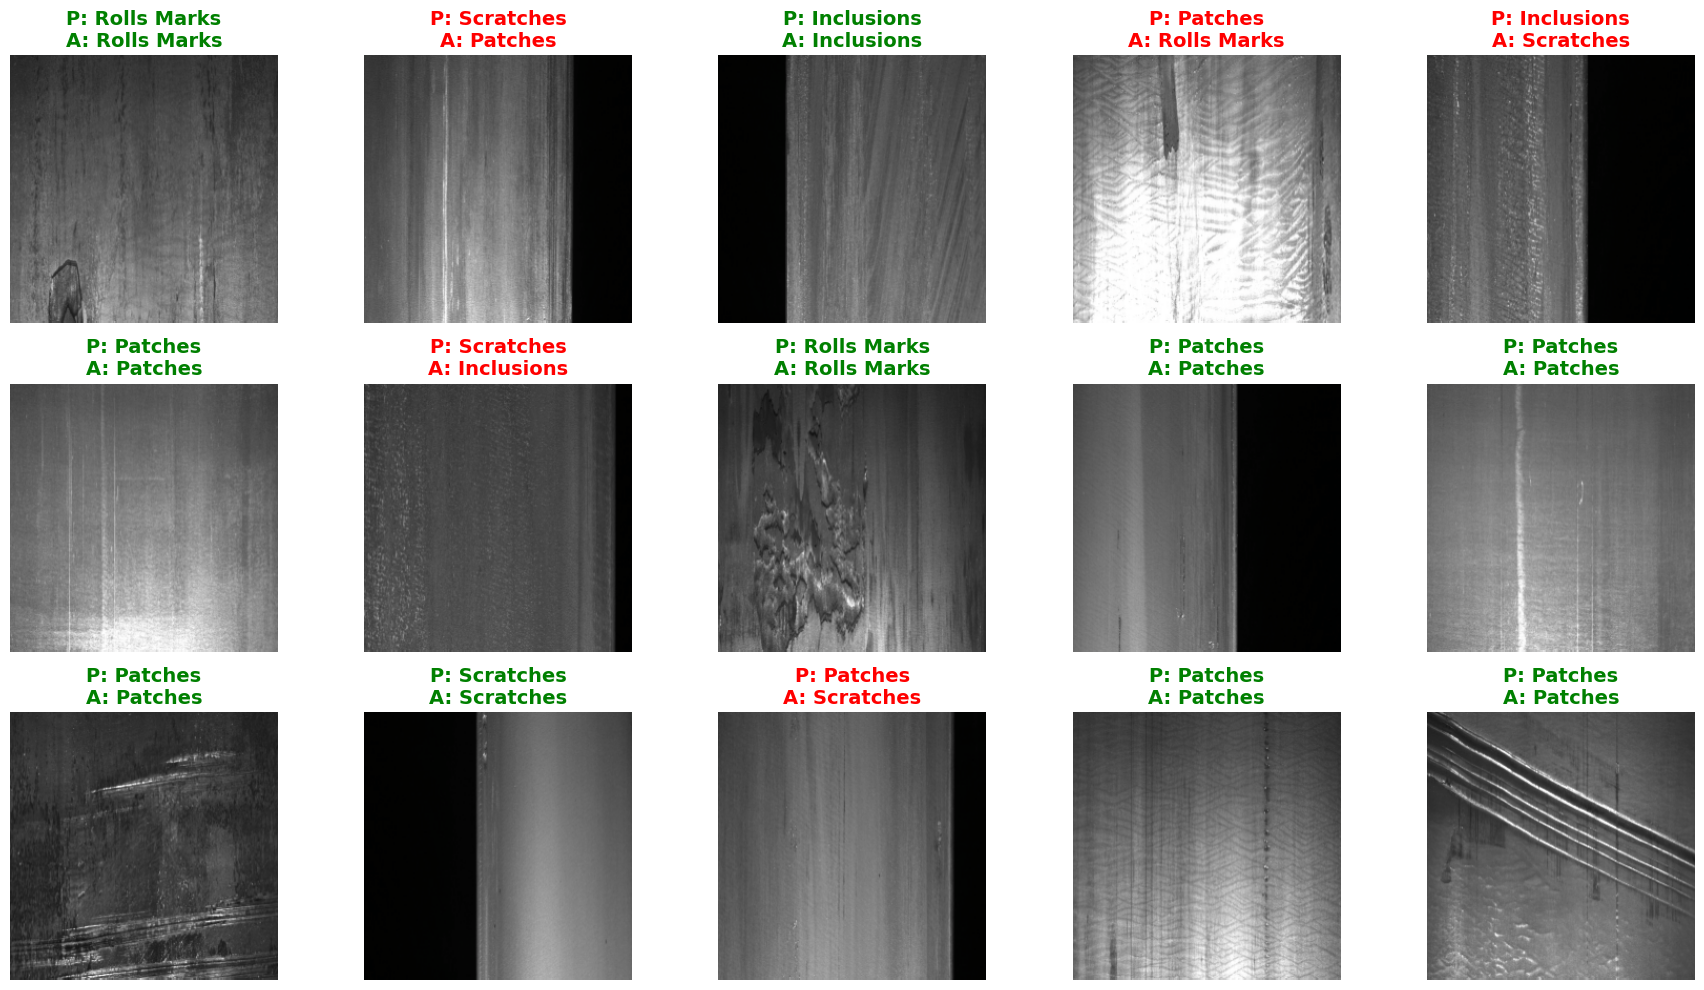

In [26]:
# Visualize Predictions on Test Set - VGG16
model_vgg16.eval()
plt.figure(figsize=(18, 10))

images_batch, labels_batch = next(iter(test_loader))
images_batch_dev = images_batch.to(device)

with torch.no_grad():
    outputs = model_vgg16(images_batch_dev)
    _, predicted_classes = torch.max(outputs, 1)

for i in range(min(15, len(images_batch))):
    ax = plt.subplot(3, 5, i + 1)
    img = inv_normalize(images_batch[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    plt.imshow(img)

    actual_class_idx = labels_batch[i].item()
    actual_class     = class_names[actual_class_idx]
    predicted_class  = class_names[predicted_classes[i].item()]

    color = 'green' if actual_class_idx == predicted_classes[i].item() else 'red'
    plt.title(f"P: {predicted_class}\nA: {actual_class}",
              color=color, fontweight='bold', fontsize=14)
    plt.axis('off')

plt.tight_layout()
plt.show()


Computing predictions on test set...
Test Accuracy: 0.7412 (74.12%)


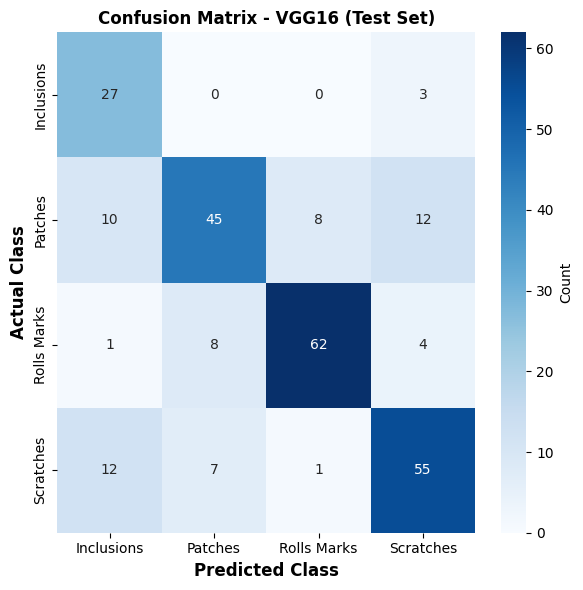


CLASSIFICATION REPORT - VGG16 (Test Set)
              precision    recall  f1-score   support

  Inclusions     0.5400    0.9000    0.6750        30
     Patches     0.7500    0.6000    0.6667        75
 Rolls Marks     0.8732    0.8267    0.8493        75
   Scratches     0.7432    0.7333    0.7383        75

    accuracy                         0.7412       255
   macro avg     0.7266    0.7650    0.7323       255
weighted avg     0.7596    0.7412    0.7424       255



In [27]:
# Confusion Matrix and Classification Report - VGG16 (Test Dataset)
print("Computing predictions on test set...")
model_vgg16.eval()
ypred_test, ylabel_test = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model_vgg16(images)
        _, predicted = torch.max(outputs, 1)
        ypred_test.extend(predicted.cpu().numpy())
        ylabel_test.extend(labels.numpy())

cm_test = confusion_matrix(ylabel_test, ypred_test)
test_accuracy = np.sum(np.array(ypred_test) == np.array(ylabel_test)) / len(ylabel_test)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("="*60)

plt.figure(figsize=(6, 6))
sns.heatmap(cm_test, annot=True, cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            fmt='d', cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Class', fontsize=12, fontweight='bold')
plt.ylabel('Actual Class', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - VGG16 (Test Set)', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CLASSIFICATION REPORT - VGG16 (Test Set)")
print("="*60)
print(classification_report(ylabel_test, ypred_test,
                             labels=list(range(len(class_names))),
                             target_names=class_names, digits=4))


## Fine-tuning VGG16 - Unfreezing the last Conv block (block5) 

## Fine-Tuning: Unfreezing the Last Conv Block

So far the entire VGG16 backbone was frozen and only the new classifier head was trained (~2.23M parameters). We now **unfreeze the last convolutional block (block5)** so its filters can adapt from generic ImageNet features to the specific textures and patterns of steel-surface defects.

This raises the trainable parameter count to roughly **9.3M**, since block5's three convolutional layers add about 7M trainable weights on top of the head.

**Why this can affect results:**
- **Upside** — the deepest conv features become specialized to our defect classes, which can improve accuracy when the target domain differs from ImageNet.
- **Risk** — more trainable parameters on a small dataset (~1,186 unique images) increases the chance of **overfitting**. To mitigate this, we keep the early blocks frozen (their edge/texture features generalize well) and fine-tune the backbone with a **much lower learning rate** than the head, so the pretrained weights are nudged rather than overwritten.

In [22]:
## Transfer Learning with VGG16 - last conv block (block5) unfrozen for fine-tuning 
class VGG16_FT(nn.Module):
    """
    VGG16 transfer learning with block5 fine-tuning.
    Block5 is unfrozen while earlier convolution layers stay frozen.
    """
    def __init__(self, num_classes, unfreeze_layer=24):
        super(VGG16_FT, self).__init__()

        # Load pretrained VGG16
        self.vgg16 = models.vgg16(
            weights=models.VGG16_Weights.IMAGENET1K_V1
        )

        # Freeze all pretrained layers
        for param in self.vgg16.parameters():
            param.requires_grad = False

        # Remove final ImageNet classifier layer
        self.vgg16.classifier = nn.Sequential(
            *list(self.vgg16.classifier.children())[:-1]
        )

        # Custom classifier
        self.own_layers = nn.Sequential(
            nn.Linear(4096, 512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, num_classes)
        )

        # Unfreeze block5
        self.unfreeze_from(unfreeze_layer)

    def forward(self, x):
        x = self.vgg16(x)
        x = self.own_layers(x)
        return x

    def unfreeze_from(self, layer_idx=24):
        """
        Unfreeze VGG16 feature layers from layer_idx onward.

        VGG16 block5 starts at index 24.
        """

        for idx, layer in enumerate(self.vgg16.features):

            trainable = idx >= layer_idx

            for param in layer.parameters():
                param.requires_grad = trainable
                
# Model summary
print("VGG16 Model with custom classifier ")
# Build model
model_vgg16 = VGG16_Model(num_classes=len(class_names)).to(device)

# Model summary
print(summary(
    model_vgg16,
    input_size=(1,3,224,224),
    depth=10,
    col_names=["input_size", "output_size", "kernel_size", "num_params"]))


# Unfreeze the last conv block for fine-tuning
model_vgg16_ft = VGG16_FT(num_classes=len(class_names)).to(device)

# Model summary
print("VGG16 Fine-Tuning Model (block5 unfrozen)")
print(summary(
    model_vgg16_ft,
    input_size=(1,3,224,224),
    depth=10,
    col_names=["input_size", "output_size", "kernel_size", "num_params"]))

VGG16 Model with custom classifier 
Layer (type:depth-idx)                   Input Shape               Output Shape              Kernel Shape              Param #
VGG16_Model                              [1, 3, 224, 224]          [1, 4]                    --                        --
├─VGG: 1-1                               [1, 3, 224, 224]          [1, 4096]                 --                        --
│    └─Sequential: 2-1                   [1, 3, 224, 224]          [1, 512, 7, 7]            --                        --
│    │    └─Conv2d: 3-1                  [1, 3, 224, 224]          [1, 64, 224, 224]         [3, 3]                    (1,792)
│    │    └─ReLU: 3-2                    [1, 64, 224, 224]         [1, 64, 224, 224]         --                        --
│    │    └─Conv2d: 3-3                  [1, 64, 224, 224]         [1, 64, 224, 224]         [3, 3]                    (36,928)
│    │    └─ReLU: 3-4                    [1, 64, 224, 224]         [1, 64, 224, 224]         -

In [ ]:
# --- learning rates -----------------------------
# Backbone (unfrozen block5) trains slowly to preserve pretrained features;
# the new classifier head trains faster.
backbone_params = [p for p in model_vgg16_ft.vgg16.parameters() if p.requires_grad]
head_params = list(model_vgg16_ft.own_layers.parameters())

optimizer_vgg16_ft = optim.Adam([
    {"params": backbone_params, "lr": 1e-5},   # fine-tune slowly
    {"params": head_params,     "lr": 1e-4},   # train head faster
])


# If you are running on the LUMI cluster, do not execute this cell interactively. Instead, submit the script as a batch job to the SLURM queue system:
# sbatch run.sh VGG_FT_classifier.py

criterion = nn.CrossEntropyLoss()
optimizer_vgg16_ft = optim.Adam(model_vgg16_ft.parameters(), lr=0.001)
EPOCHS = 10

start_start = time.time()
print("Training VGG16 Transfer Learning Model...")
history_vgg16_ft = train_model(
    model_vgg16_ft,
    train_loader,
    val_loader,
    optimizer_vgg16_ft,
    criterion,
    EPOCHS,
    "VGG16_FT"
)

# Training time
end_time = time.time()
print(f"\nTotal training time: {(end_time-start_time):.2f} seconds")
print(f"Average time per epoch: {(end_time-start_time)/EPOCHS:.2f} seconds")


# Save VGG16 fine-tunned Model
torch.save(model_vgg16_ft.state_dict(), 'model_vgg16_ft_model.pth')
print("VGG16 Fine-tunned model saved as 'model_vgg16_ft_model.pth'")

In [32]:
#load the tranied model and history of training
storage_path = f"/projappl/project_465002387/DEEP_Inspection_Material_Science/users/{os.environ['USER']}/"
model_path = os.path.join(storage_path, "models", "vgg16_ft_defect_classifier.pth")


checkpoint = torch.load(model_path, map_location=device)
model_vgg16_ft = VGG16_FT(num_classes=len(class_names)).to(device)

model_vgg16_ft.load_state_dict(checkpoint["model_state_dict"])
model_vgg16_ft.eval()

history_vgg16_ft = checkpoint["history"]
print(f"Loaded model from: {model_path}")

Loaded model from: /projappl/project_465002387/DEEP_Inspection_Material_Science/users/saeedima/models/vgg16_ft_defect_classifier.pth


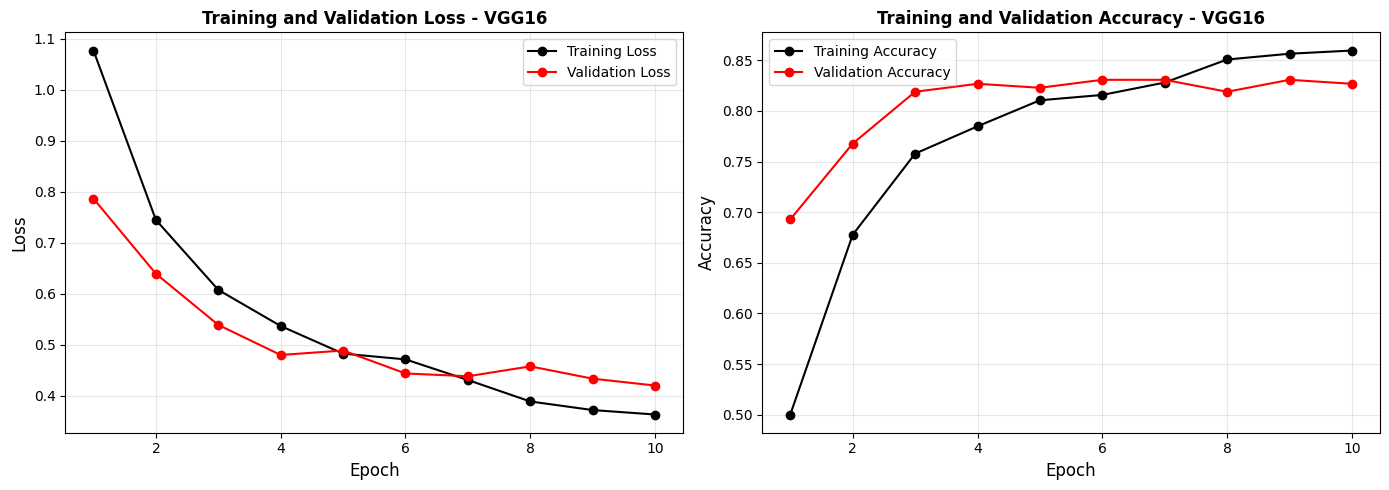

In [33]:
# Plot Training History for VGG16 - last conv block (block5) unfrozen for fine-tuning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(np.arange(1, len(history_vgg16_ft["loss"]) + 1), history_vgg16_ft['loss'],
             color='black', label='Training Loss', marker='o')
axes[0].plot(np.arange(1, len(history_vgg16_ft["loss"]) + 1), history_vgg16_ft['val_loss'],
             color='red', label='Validation Loss', marker='o')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss - VGG16', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(np.arange(1, len(history_vgg16_ft["loss"]) + 1), history_vgg16_ft['accuracy'],
             color='black', label='Training Accuracy', marker='o')
axes[1].plot(np.arange(1, len(history_vgg16_ft["loss"]) + 1), history_vgg16_ft['val_accuracy'],
             color='red', label='Validation Accuracy', marker='o')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Validation Accuracy - VGG16', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


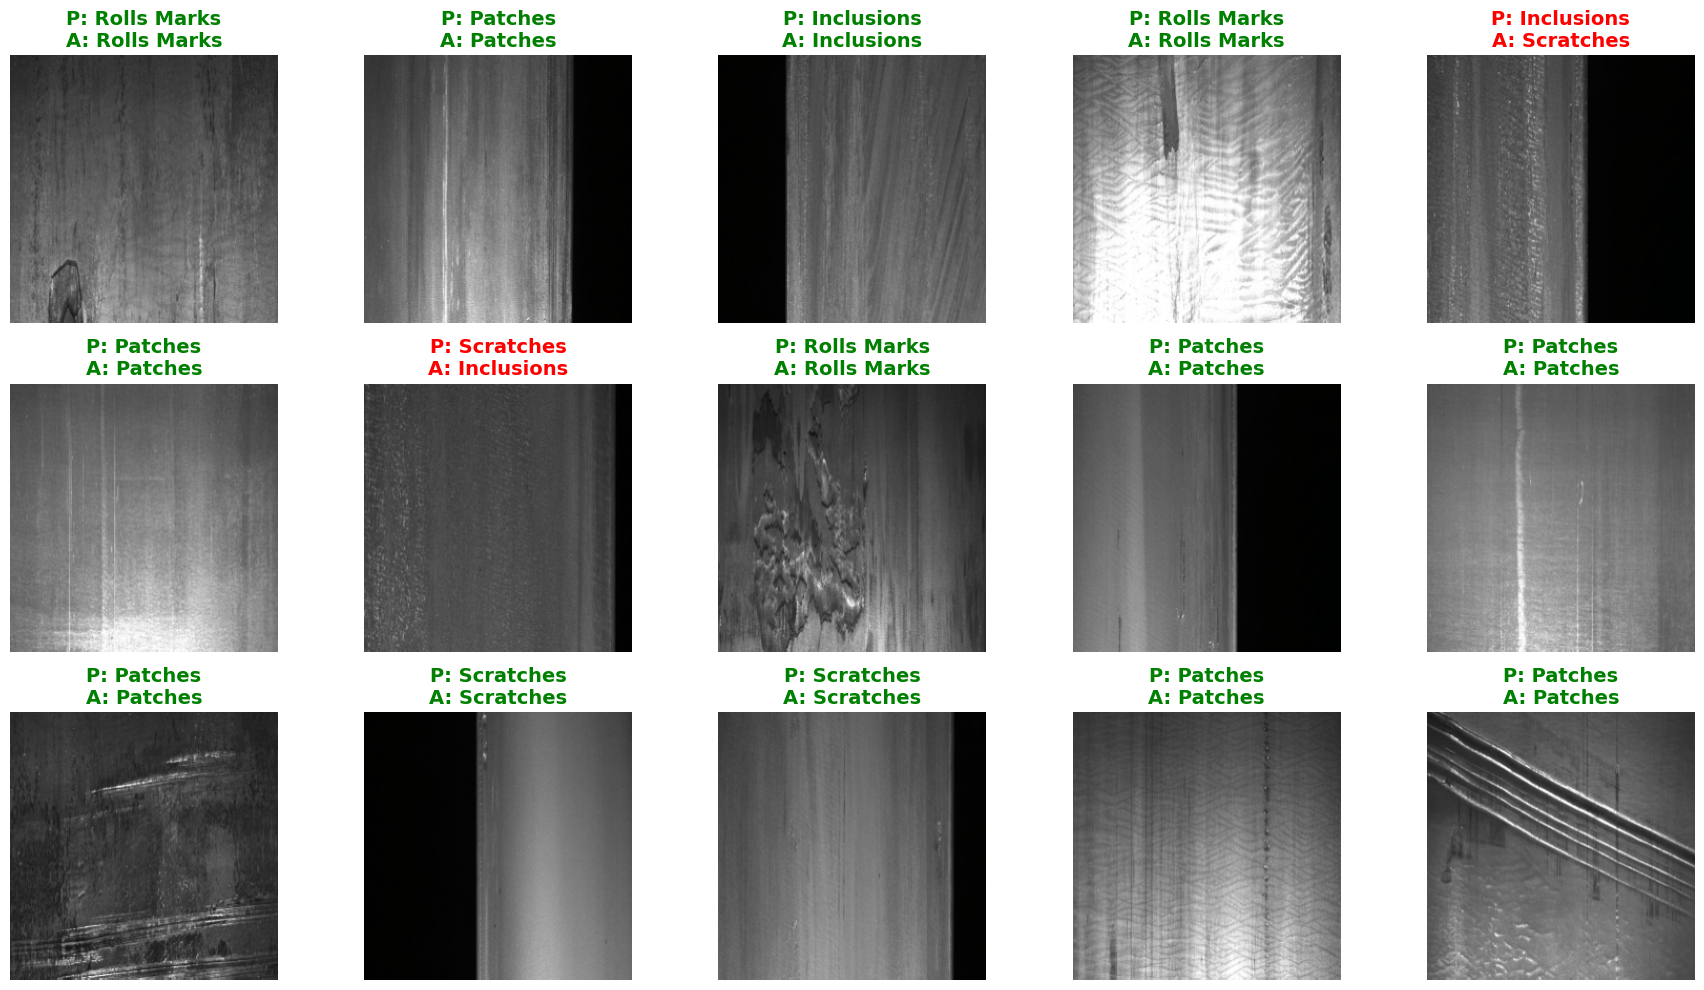

In [34]:
# Visualize Predictions on Test Set - VGG16 - last conv block (block5) unfrozen for fine-tuning
model_vgg16_ft.eval()
plt.figure(figsize=(18, 10))

images_batch, labels_batch = next(iter(test_loader))
images_batch_dev = images_batch.to(device)

with torch.no_grad():
    outputs = model_vgg16_ft(images_batch_dev)
    _, predicted_classes = torch.max(outputs, 1)

for i in range(min(15, len(images_batch))):
    ax = plt.subplot(3, 5, i + 1)
    img = inv_normalize(images_batch[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    plt.imshow(img)

    actual_class_idx = labels_batch[i].item()
    actual_class     = class_names[actual_class_idx]
    predicted_class  = class_names[predicted_classes[i].item()]

    color = 'green' if actual_class_idx == predicted_classes[i].item() else 'red'
    plt.title(f"P: {predicted_class}\nA: {actual_class}",
              color=color, fontweight='bold', fontsize=14)
    plt.axis('off')

plt.tight_layout()
plt.show()


Computing predictions on test set...
Test Accuracy: 0.8039 (80.39%)


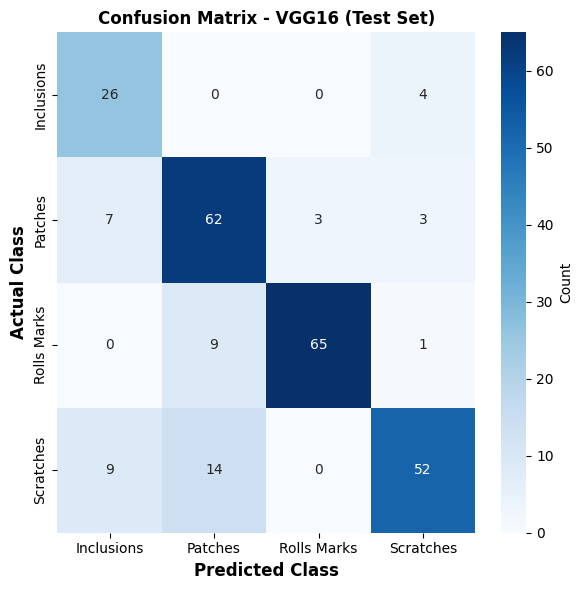


CLASSIFICATION REPORT - VGG16 (Test Set)
              precision    recall  f1-score   support

  Inclusions     0.6190    0.8667    0.7222        30
     Patches     0.7294    0.8267    0.7750        75
 Rolls Marks     0.9559    0.8667    0.9091        75
   Scratches     0.8667    0.6933    0.7704        75

    accuracy                         0.8039       255
   macro avg     0.7928    0.8133    0.7942       255
weighted avg     0.8234    0.8039    0.8069       255



In [35]:
# Confusion Matrix and Classification Report - VGG16 (Test) - last conv block (block5) unfrozen for fine-tuning
print("Computing predictions on test set...")
model_vgg16_ft.eval()
ypred_test, ylabel_test = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model_vgg16_ft(images)
        _, predicted = torch.max(outputs, 1)
        ypred_test.extend(predicted.cpu().numpy())
        ylabel_test.extend(labels.numpy())

cm_test = confusion_matrix(ylabel_test, ypred_test)
test_accuracy = np.sum(np.array(ypred_test) == np.array(ylabel_test)) / len(ylabel_test)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("="*60)

plt.figure(figsize=(6, 6))
sns.heatmap(cm_test, annot=True, cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            fmt='d', cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Class', fontsize=12, fontweight='bold')
plt.ylabel('Actual Class', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - VGG16 (Test Set)', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CLASSIFICATION REPORT - VGG16 (Test Set)")
print("="*60)
print(classification_report(ylabel_test, ypred_test,
                             labels=list(range(len(class_names))),
                             target_names=class_names, digits=4))
print("="*60)


# Transfer Learning with ResNet50

In [7]:
![ResNet50](../Fig/03_hansdon_ResNet50.png)

/bin/bash: -c: line 1: syntax error near unexpected token `../Fig/03_hansdon_ResNet50.png'
/bin/bash: -c: line 1: `[ResNet50](../Fig/03_hansdon_ResNet50.png)'


In [10]:
# Load pre-trained ResNet50 base model with IMAGENET1K_V2 weights
base_model_resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

summary(
    base_model_resnet,
    input_size=(1,3,224,224),
    depth=10,
    col_names=["input_size", "output_size", "kernel_size", "num_params"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Kernel Shape              Param #
ResNet                                   [1, 3, 224, 224]          [1, 1000]                 --                        --
├─Conv2d: 1-1                            [1, 3, 224, 224]          [1, 64, 112, 112]         [7, 7]                    9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         [1, 64, 112, 112]         --                        128
├─ReLU: 1-3                              [1, 64, 112, 112]         [1, 64, 112, 112]         --                        --
├─MaxPool2d: 1-4                         [1, 64, 112, 112]         [1, 64, 56, 56]           3                         --
├─Sequential: 1-5                        [1, 64, 56, 56]           [1, 256, 56, 56]          --                        --
│    └─Bottleneck: 2-1                   [1, 64, 56, 56]           [1, 256, 56, 56]          --                        --
│    │    └─Con

In [11]:
# Build ResNet50 Transfer Learning Model
class ResNet50_Model(nn.Module):
    def __init__(self, num_classes):
        super(ResNet50_Model, self).__init__()
        # Load pretrained ResNet50
        self.resnet50 = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V2
        )

        # Freeze all pretrained layers
        for param in self.resnet50.parameters():
            param.requires_grad = False

        # Replace the original ImageNet classifier
        in_features = self.resnet50.fc.in_features

        self.resnet50.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.resnet50(x)
        return x
       
model_resnet50 = ResNet50_Model(num_classes=len(class_names)).to(device)
summary(
    model_resnet50,
    input_size=(1,3,224,224),
    depth=10,
    col_names=["input_size", "output_size", "kernel_size", "num_params"])

Layer (type:depth-idx)                        Input Shape               Output Shape              Kernel Shape              Param #
ResNet50_Model                                [1, 3, 224, 224]          [1, 4]                    --                        --
├─ResNet: 1-1                                 [1, 3, 224, 224]          [1, 4]                    --                        --
│    └─Conv2d: 2-1                            [1, 3, 224, 224]          [1, 64, 112, 112]         [7, 7]                    (9,408)
│    └─BatchNorm2d: 2-2                       [1, 64, 112, 112]         [1, 64, 112, 112]         --                        (128)
│    └─ReLU: 2-3                              [1, 64, 112, 112]         [1, 64, 112, 112]         --                        --
│    └─MaxPool2d: 2-4                         [1, 64, 112, 112]         [1, 64, 56, 56]           3                         --
│    └─Sequential: 2-5                        [1, 64, 56, 56]           [1, 256, 56, 56]          

In [ ]:
# Train ResNet50 Model
# If you are running on the LUMI cluster, do not execute this cell interactively. Instead, submit the script as a batch job to the SLURM queue system:
# sbatch run.sh ResNet50_classifier.py

criterion = nn.CrossEntropyLoss()
optimizer_resnet = optim.Adam(model_resnet50.resnet50.fc.parameters(), lr=0.001)
EPOCHS = 10

start_time = time.time()
print("Training ResNet50 Transfer Learning Model...")

history_resnet = train_model(
    model_resnet50 ,
    train_loader,
    val_loader,
    optimizer_resnet,
    criterion,
    EPOCHS,
    "ResNet50"
)

# Training time
end_time = time.time()
print(f"\nTotal training time: {(end_time-start_time):.2f} seconds")
print(f"Average time per epoch: {(end_time-start_time)/EPOCHS:.2f} seconds")


# Save ResNet50 Model
torch.save(model_resnet50.state_dict(), 'model_resnet50_model.pth')
print("model resnet50 saved as 'model_resnet50_model.pth'")

In [20]:
#load the tranied model and history of training
storage_path = f"/projappl/project_465002387/DEEP_Inspection_Material_Science/users/{os.environ['USER']}/"
model_path = os.path.join(storage_path, "models", "resnet50_defect_classifier.pth")


checkpoint = torch.load(model_path, map_location=device)
model_resnet50 = ResNet50_Model(num_classes=len(class_names)).to(device)

model_resnet50.load_state_dict(checkpoint["model_state_dict"])
model_resnet50.eval()

history_resnet50 = checkpoint["history"]
print(f"Loaded model from: {model_path}")

Loaded model from: /projappl/project_465002387/DEEP_Inspection_Material_Science/users/saeedima/models/resnet50_defect_classifier.pth


Computing predictions on test set...
Test Accuracy: 0.8392 (83.92%)


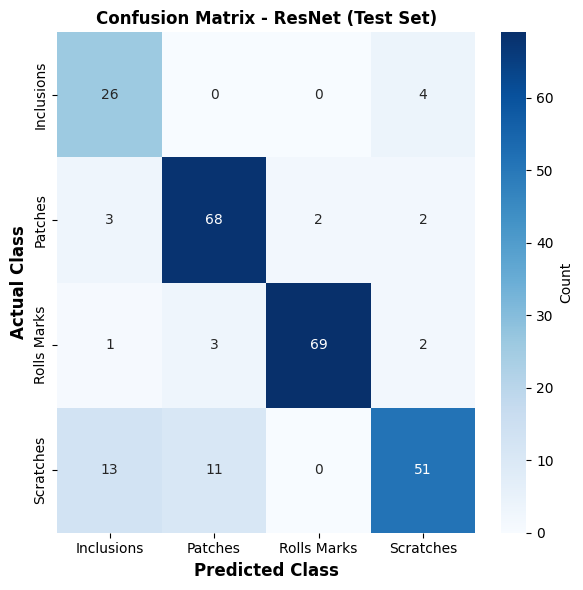


CLASSIFICATION REPORT - ResNet(Test Set)
              precision    recall  f1-score   support

  Inclusions     0.6047    0.8667    0.7123        30
     Patches     0.8293    0.9067    0.8662        75
 Rolls Marks     0.9718    0.9200    0.9452        75
   Scratches     0.8644    0.6800    0.7612        75

    accuracy                         0.8392       255
   macro avg     0.8175    0.8433    0.8212       255
weighted avg     0.8551    0.8392    0.8405       255



In [23]:
# Confusion Matrix and Classification Report - ResNet50 (Test)
print("Computing predictions on test set...")
model_resnet50.eval()
ypred_test, ylabel_test = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model_resnet50(images)
        _, predicted = torch.max(outputs, 1)
        ypred_test.extend(predicted.cpu().numpy())
        ylabel_test.extend(labels.numpy())

cm_test = confusion_matrix(ylabel_test, ypred_test)
test_accuracy = np.sum(np.array(ypred_test) == np.array(ylabel_test)) / len(ylabel_test)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("="*60)

plt.figure(figsize=(6, 6))
sns.heatmap(cm_test, annot=True, cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            fmt='d', cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Class', fontsize=12, fontweight='bold')
plt.ylabel('Actual Class', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - ResNet (Test Set)', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CLASSIFICATION REPORT - ResNet(Test Set)")
print("="*60)
print(classification_report(ylabel_test, ypred_test,
                             labels=list(range(len(class_names))),
                             target_names=class_names, digits=4))
print("="*60)

# Importance of 1×1 Convolution layer and the Inception (GoogleLeNet) Architecture

## Why Do We Need a 1×1 Convolution Layer?

A **1×1 convolution** may seem unusual but its commonly used in deep learning and called a **bottleneck layer** because it reduces the number of channels before expensive convolutions.
Without the bottleneck, large convolutions like **3×3** and **5×5** would be extremely expensive. Benefits of 1×1 Convolution

- **Reduces the number of channels (feature maps)** before applying expensive convolutions.
- **Decreases computational cost** and memory usage.
- **Adds non-linearity** when followed by an activation function (e.g., ReLU).
- **Learns better feature combinations** by mixing information across channels.


## The Inception Module

The **Inception module** was introduced in **GoogleLeNet (Inception-v1)**. Instead of choosing one convolution size, perform multiple convolutions in parallel and combine their outputs.

Each Inception module contains four parallel branches is shown below:

![inception module](../Fig/03_handson_inception_module.png)


## GoogleLeNet Architecture

**GoogleLeNet** (also known as **Inception-v1**) was introduced by Google in **2014**. It is built by **stacking multiple Inception modules** one after another.
GoogleLeNet architecture is shown below:

![GoogleLeNet](../Fig/03_handson_GoogleleNet.png)

For a more detailed explanation of the Inception (GoogleLeNet) architecture, take a look at this Medium article: Understanding Inception: Simplifying the Network Architecture
https://medium.com/swlh/understanding-inception-simplifying-the-network-architecture-54cd31d38949


## Assignment: Transfer Learning with GoogLeNet "Going Deeper with Convolutions" (2014)
- Load the pre-trained GoogLeNet model.
- Print the model architecture.
- Implement transfer learning by removing and replacing the final classifier layer.
- Train the modified model on Severstal defect dataset.
- Compare the following with ResNet:
- Number of trainable parameters
- Model performance (e.g., accuracy, loss, training time)

** To submit the job to LUMI, run:  sbatch run.sh 03-googlelenet.py

# Solution for GoogLenet-Transfer learning

In [37]:
# Build GoogleLeNet Transfer Learning Model
class GoogleLeNet_Model(nn.Module):
    def __init__(self, num_classes):
        super(GoogleLeNet_Model, self).__init__()

        # Load pretrained GoogleLeNet
        self.googlenet = models.googlenet(
            weights=models.GoogLeNet_Weights.IMAGENET1K_V1,
            aux_logits=True
        )

        # Freeze all pretrained layers
        for param in self.googlenet.parameters():
            param.requires_grad = False

        # Replace original ImageNet classifier
        in_features = self.googlenet.fc.in_features

        self.googlenet.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

        # Disable auxiliary classifiers for transfer learning
        self.googlenet.aux1 = None
        self.googlenet.aux2 = None

    def forward(self, x):
        x = self.googlenet(x)
        return x

# GoogleLeNet Transfer Learning Model
model_googlenet = GoogleLeNet_Model(
    num_classes=len(class_names)
).to(device)


summary(
    model_googlenet,
    input_size=(1,3,224,224),
    depth=10,
    col_names=[
        "input_size",
        "output_size",
        "kernel_size",
        "num_params"
    ]
)

/usr/local/lib/python3.11/dist-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


Layer (type:depth-idx)                        Input Shape               Output Shape              Kernel Shape              Param #
GoogleLeNet_Model                             [1, 3, 224, 224]          [1, 4]                    --                        --
├─GoogLeNet: 1-1                              [1, 3, 224, 224]          [1, 4]                    --                        --
│    └─BasicConv2d: 2-1                       [1, 3, 224, 224]          [1, 64, 112, 112]         --                        --
│    │    └─Conv2d: 3-1                       [1, 3, 224, 224]          [1, 64, 112, 112]         [7, 7]                    (9,408)
│    │    └─BatchNorm2d: 3-2                  [1, 64, 112, 112]         [1, 64, 112, 112]         --                        (128)
│    └─MaxPool2d: 2-2                         [1, 64, 112, 112]         [1, 64, 56, 56]           3                         --
│    └─BasicConv2d: 2-3                       [1, 64, 56, 56]           [1, 64, 56, 56]           

## Assignment: Transfer Learning with MobileNetV2

MobileNetV2 (Google, 2018) is a lightweight CNN designed for speed and efficiency on mobile and edge devices. Its key trick is the **depthwise separable convolution** — splitting a normal convolution into a cheap per-channel spatial filter followed by a 1×1 channel-mixing step — combined with **inverted residual blocks** that expand, filter, then compress the channels, with skip connections between the narrow ends.

The result is a model with only **~3.4M parameters** (vs. VGG16's ~138M) that still reaches solid ImageNet accuracy. This efficiency makes it a strong transfer-learning choice for our small dataset: fewer parameters mean faster training and less risk of overfitting. The MobileNetV2 archtecture shown below:

![MobileNetV2 moodel](../Fig/03_handson_MobileNetV2.png)


### Apply transfer learning using MobileNetV2 to build an image classification model for Steel Defect Detection dataset. You are required to:
- Load a pretrained MobileNetV2 model from torchvision. Inspect the model architecture and explore its parameters and layers.
- Freeze the pretrained feature extractor layers.
- Replace the classifier with a custom neural network head.
- Train the model on your dataset.
- Evaluate performance on validation data.

# Solution for Mobilenet-Transfer learning

In [28]:
# Build Mobilenet_V2 Transfer Learning Model
class Mobilenet_Model(nn.Module):
    def __init__(self, num_classes):
        super(Mobilenet_Model, self).__init__()

        # Load pretrained GoogleLeNet
        self.mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

        # Freeze all pretrained layers
        for param in self.mobilenet.parameters():
            param.requires_grad = False

        # Replace original ImageNet classifier
        in_features = self.mobilenet.classifier[1].in_features

        self.mobilenet.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.mobilenet(x)
        return x

# GoogleLeNet Transfer Learning Model
model_mobilenet = Mobilenet_Model(num_classes=len(class_names)).to(device)


summary(
    model_mobilenet,
    input_size=(1,3,224,224),
    depth=10,
    col_names=[
        "input_size",
        "output_size",
        "kernel_size",
        "num_params"
    ]
)

Layer (type:depth-idx)                                  Input Shape               Output Shape              Kernel Shape              Param #
Mobilenet_Model                                         [1, 3, 224, 224]          [1, 4]                    --                        --
├─MobileNetV2: 1-1                                      [1, 3, 224, 224]          [1, 4]                    --                        --
│    └─Sequential: 2-1                                  [1, 3, 224, 224]          [1, 1280, 7, 7]           --                        --
│    │    └─Conv2dNormActivation: 3-1                   [1, 3, 224, 224]          [1, 32, 112, 112]         --                        --
│    │    │    └─Conv2d: 4-1                            [1, 3, 224, 224]          [1, 32, 112, 112]         [3, 3]                    (864)
│    │    │    └─BatchNorm2d: 4-2                       [1, 32, 112, 112]         [1, 32, 112, 112]         --                        (64)
│    │    │    └─ReLU6: 4-3    

## Summary: Comparison of Transfer Learning Models (VGG16, ResNet50, GoogLeNet, and MobileNetV2)

The comparison of popular deep learning architectures used for transfer learning: **VGG16, ResNet50, GoogLeNet (Inception v1), and MobileNetV2**. The table summarizes the main characteristics, key ideas, strengths, weaknesses, and trade-offs of each model.


|              | VGG16 | ResNet50 | GoogLeNet (Inception v1) | MobileNetV2 |
|--------------|-------|----------|---------------------------|-------------|
| Year | 2014 | 2015 | 2014 | 2018 |
| Key idea | Stacked 3×3 convs | Residual/skip connections | Inception modules (multi-scale convs) | Depthwise separable + inverted residuals |
| Parameters | ~138M | ~25.6M | ~6.8M | ~3.4M |
| Depth | 16 layers | 50 layers | 22 layers | 53 layers |
| Designed for | Accuracy, simplicity | Very deep networks | Efficient feature extraction | Mobile/edge efficiency |
| Trade-off | Heavy, slow | Balanced | Efficient but complex | Lightest, slight accuracy cost |

# Vision Transformer (ViT) for Defect Classification

Vision Transformers use self-attention mechanisms instead of convolutions, allowing the model to capture global spatial relationships in images.


In [38]:
# Load pre-trained Vision Transformer (ViT-B/16) with ImageNet weights
base_model_vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)


summary(
    base_model_vit,
    input_size=(1,3,224,224),
    depth=10,
    col_names=["input_size", "output_size", "kernel_size", "num_params"])

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /users/saeedima/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 215MB/s] 


Layer (type:depth-idx)                        Input Shape               Output Shape              Kernel Shape              Param #
VisionTransformer                             [1, 3, 224, 224]          [1, 1000]                 --                        768
├─Conv2d: 1-1                                 [1, 3, 224, 224]          [1, 768, 14, 14]          [16, 16]                  590,592
├─Encoder: 1-2                                [1, 197, 768]             [1, 197, 768]             --                        151,296
│    └─Dropout: 2-1                           [1, 197, 768]             [1, 197, 768]             --                        --
│    └─Sequential: 2-2                        [1, 197, 768]             [1, 197, 768]             --                        --
│    │    └─EncoderBlock: 3-1                 [1, 197, 768]             [1, 197, 768]             --                        --
│    │    │    └─LayerNorm: 4-1               [1, 197, 768]             [1, 197, 768]          

In [39]:
# Build ViT Transfer Learning Model
class ViTTransfer(nn.Module):
    """Pretrained ViT-B/16 with a frozen backbone and a new classifier head.

    torchvision's ViT-B/16 expects 224x224 input, but our pipeline uses
    IMAGE_SIZE=255, so we resize inside forward() to keep the data pipeline
    untouched and consistent with the other models.
    """
    def __init__(self, num_classes):
        super().__init__()
        self.vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

        # Freeze all pretrained layers
        for param in self.vit.parameters():
            param.requires_grad = False

        # ViT's classifier lives in `heads.head`; replace it
        in_features = self.vit.heads.head.in_features   # 768 for ViT-B/16
        self.vit.heads.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # Resize 255 -> 224 to match ViT's fixed patch/positional embeddings
        x = F.interpolate(x, size=224, mode="bilinear", align_corners=False)
        return self.vit(x)


def build_vit_model():
    return ViTTransfer(num_classes=len(class_names))

model_vit = build_vit_model().to(device)

summary(
    model_vit,
    input_size=(1,3,224,224),
    depth=10,
    col_names=["input_size", "output_size", "kernel_size", "num_params"])

Layer (type:depth-idx)                             Input Shape               Output Shape              Kernel Shape              Param #
ViTTransfer                                        [1, 3, 224, 224]          [1, 4]                    --                        --
├─VisionTransformer: 1-1                           [1, 3, 224, 224]          [1, 4]                    --                        768
│    └─Conv2d: 2-1                                 [1, 3, 224, 224]          [1, 768, 14, 14]          [16, 16]                  (590,592)
│    └─Encoder: 2-2                                [1, 197, 768]             [1, 197, 768]             --                        151,296
│    │    └─Dropout: 3-1                           [1, 197, 768]             [1, 197, 768]             --                        --
│    │    └─Sequential: 3-2                        [1, 197, 768]             [1, 197, 768]             --                        --
│    │    │    └─EncoderBlock: 4-1                 [1, 197

In [ ]:
# Train ViT Model
# If you are running on the LUMI cluster, do not execute this cell interactively. Instead, submit the script as a batch job to the SLURM queue system:
# sbatch run.sh Vit_classifier.py

criterion = nn.CrossEntropyLoss()
# Only the new head params require grad, so pass those to the optimizer
optimizer_vit_tl = optim.Adam(
    [p for p in model_vit.parameters() if p.requires_grad], lr=0.001)

EPOCHS = 10
start_time = time.time()
print("Training ViT Transfer Learning Model...")

history_vit_tl = train_model(
    model_vit ,
    train_loader,
    val_loader,
    optimizer_vit_tl,
    criterion,
    EPOCHS,
    "ViT"
)

# Training time
end_time = time.time()
print(f"\nTotal training time: {(end_time-start_time):.2f} seconds")
print(f"Average time per epoch: {(end_time-start_time)/EPOCHS:.2f} seconds")


# Save ViT transfer learned Model
torch.save(model_vit.state_dict(), 'model_vit_model.pth')
print("model viT saved as 'model_vit_model.pth'")

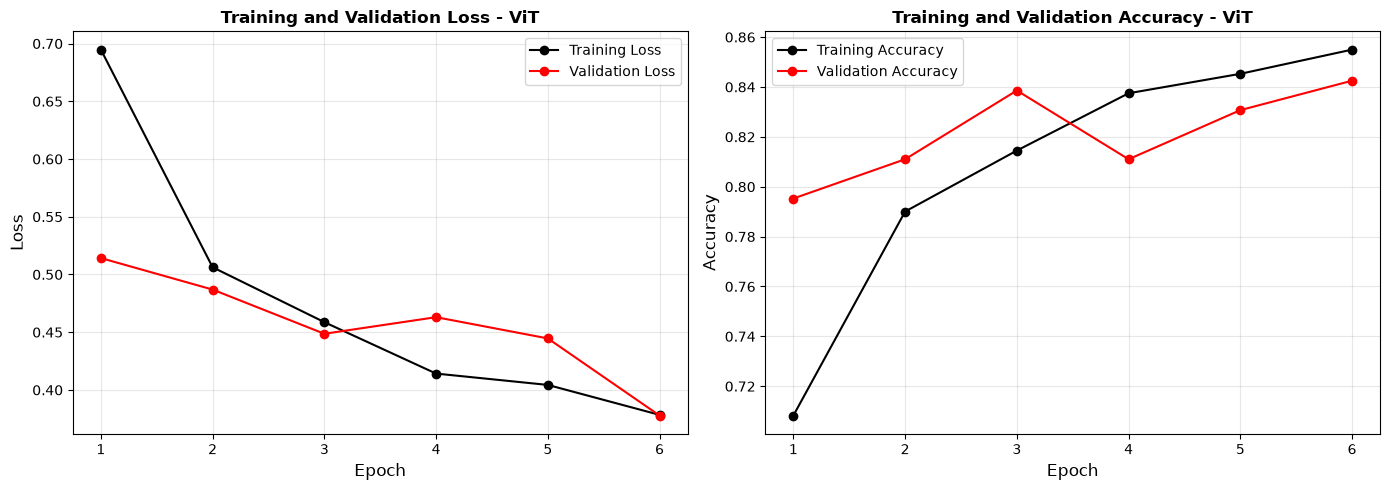

In [37]:
# Plot Training History for ViT
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(np.arange(1, EPOCHS + 1), history_vit_tl['loss'],
             color='black', label='Training Loss', marker='o')
axes[0].plot(np.arange(1, EPOCHS + 1), history_vit_tl['val_loss'],
             color='red', label='Validation Loss', marker='o')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss - ViT', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(np.arange(1, EPOCHS + 1), history_vit_tl['accuracy'],
             color='black', label='Training Accuracy', marker='o')
axes[1].plot(np.arange(1, EPOCHS + 1), history_vit_tl['val_accuracy'],
             color='red', label='Validation Accuracy', marker='o')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Validation Accuracy - ViT', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Computing predictions on test set...
Test Accuracy: 0.8392 (83.92%)


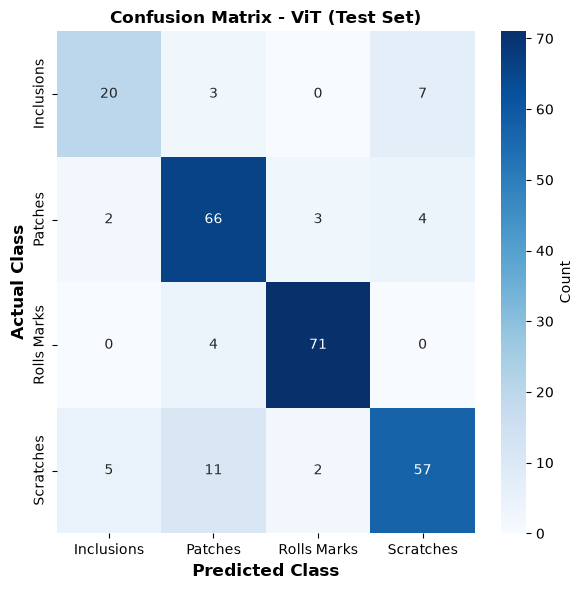


CLASSIFICATION REPORT - ViT (Test Set)
              precision    recall  f1-score   support

  Inclusions     0.7407    0.6667    0.7018        30
     Patches     0.7857    0.8800    0.8302        75
 Rolls Marks     0.9342    0.9467    0.9404        75
   Scratches     0.8382    0.7600    0.7972        75

    accuracy                         0.8392       255
   macro avg     0.8247    0.8133    0.8174       255
weighted avg     0.8395    0.8392    0.8378       255



In [38]:
# Confusion Matrix and Classification Report - ViT (Test)
print("Computing predictions on test set...")
model_vit.eval()
ypred_test, ylabel_test = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model_vit(images)
        _, predicted = torch.max(outputs, 1)
        ypred_test.extend(predicted.cpu().numpy())
        ylabel_test.extend(labels.numpy())

cm_test = confusion_matrix(ylabel_test, ypred_test)
test_accuracy = np.sum(np.array(ypred_test) == np.array(ylabel_test)) / len(ylabel_test)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("="*60)

plt.figure(figsize=(6, 6))
sns.heatmap(cm_test, annot=True, cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            fmt='d', cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Class', fontsize=12, fontweight='bold')
plt.ylabel('Actual Class', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - ViT (Test Set)', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CLASSIFICATION REPORT - ViT (Test Set)")
print("="*60)
print(classification_report(ylabel_test, ypred_test,
                             labels=list(range(len(class_names))),
                             target_names=class_names, digits=4))
print("="*60)

In [40]:
# ============================================================
# GRAND COMPARISON OF ALL TESTED MODELS
# ============================================================
from sklearn.metrics import f1_score, precision_score, recall_score

# --- Register every trained model with its training history and training time ---
# (history is None for any model where you didn't keep the dict)
model_registry = {
    "VGG16 (frozen)":      {"model": model_vgg16,    "history": history_vgg16,    "time": time_vgg16},
    "VGG16 (fine-tuned)":  {"model": model_vgg16_ft, "history": history_vgg16_ft, "time": time_vgg16_ft},
    "MobileNetV2":         {"model": model_mbv2,     "history": history_mbv2,     "time": time_mbv2},
    "ResNet50":            {"model": model_resnet,   "history": history_resnet,   "time": time_resnet},
    "ViT-B/16":            {"model": model_vit,      "history": history_vit_tl,   "time": time_vit_tl},
}

@torch.no_grad()
def evaluate_on_test(model):
    """Return (accuracy, macro_f1, macro_precision, macro_recall, n_params)."""
    model.eval()
    y_pred, y_true = [], []
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        y_pred.extend(predicted.cpu().numpy())
        y_true.extend(labels.numpy())
    y_pred, y_true = np.array(y_pred), np.array(y_true)
    acc  = (y_pred == y_true).mean()
    f1   = f1_score(y_true, y_pred, average="macro", zero_division=0)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="macro", zero_division=0)
    n_params = sum(p.numel() for p in model.parameters())
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return acc, f1, prec, rec, n_params, n_trainable

# --- Build the comparison table ---
rows = []
for name, entry in model_registry.items():
    acc, f1, prec, rec, n_params, n_train = evaluate_on_test(entry["model"])
    hist = entry["history"]
    rows.append({
        "Model": name,
        "Test Accuracy": acc,
        "F1-score": f1,
        "Precision": prec,
        "Recall": rec,
        "Best Val Acc": max(hist["val_accuracy"]) if hist else np.nan,
        "Final Train Acc": hist["accuracy"][-1] if hist else np.nan,
        "Epochs": len(hist["loss"]) if hist else np.nan,
        "Params (M)": n_params / 1e6,
        "Trainable (M)": n_train / 1e6,
        "Training Time (s)": entry["time"],
    })

results_df = pd.DataFrame(rows).reset_index(drop=True)

print("=" * 80)
print("GRAND MODEL COMPARISON  (Test Set)")
print("=" * 80)
with pd.option_context("display.float_format", lambda x: f"{x:.4f}"):
    print(results_df.to_string(index=False))
print("=" * 80)
best_idx = results_df["Test Accuracy"].idxmax()
print(f"Best model: {results_df.iloc[best_idx]['Model']} "
      f"({results_df.iloc[best_idx]['Test Accuracy']*100:.2f}% test accuracy)")

GRAND MODEL COMPARISON  (Test Set)
             Model  Test Accuracy  F1-score  Precision  Recall  Best Val Acc  Final Train Acc  Epochs  Params (M)  Trainable (M)  Training Time (s)
    VGG16 (frozen)         0.7216    0.7227     0.7302  0.7383        0.7283           0.6060       6    136.4906         2.2300           524.1971
VGG16 (fine-tuned)         0.8235    0.8053     0.8051  0.8100        0.8465           0.8379       6    136.4906         9.3094           554.3837
       MobileNetV2         0.7647    0.7428     0.7693  0.7500        0.7756           0.7017       6      2.5528         0.3290           416.5342
          ResNet50         0.7725    0.7503     0.7658  0.7567        0.7835           0.7249       6     24.0336         0.5256           476.2668
          ViT-B/16         0.8392    0.8174     0.8247  0.8133        0.8425           0.8550       6     85.9965         0.1979           883.4368
Best model: ViT-B/16 (83.92% test accuracy)


A compact comparison:

|              | VGG16              | ResNet50                  | MobileNetV2                       | Vision Transformer (ViT-B/16)        |
|--------------|--------------------|---------------------------|-----------------------------------|--------------------------------------|
| Year         | 2014               | 2015                      | 2018                              | 2020                                 |
| Key idea     | Stacked 3×3 convs  | Residual/skip connections | Depthwise separable + inverted residuals | Self-attention over image patches |
| Parameters   | ~138M              | ~25M                      | ~3.4M                             | ~86M                                 |
| Depth        | 16 layers          | 50 layers                 | 53 layers                         | 12 transformer blocks                |
| Designed for | Accuracy, simplicity | Trainable very deep nets | Mobile/edge efficiency            | Global context, scale with big data  |
| Trade-off    | Heavy, slow        | Balanced                  | Lightest, slight accuracy cost    | Data-hungry; needs large pre-training |